# Entrega 2 — Maceta Inteligente
Modelos de clasificación supervisada para predecir la condición de la planta.

- Joaquin Bertaux
- Ignacio Borreani
- Franco Rodriguez
- Santiago Silvera

## Preparación de Datos

Pasos:
1. Carga y limpieza del dataset
2. Tratamiento de outliers
3. Codificación de la variable objetivo
4. División train/test
5. Escalado de features

### 1. Carga y limpieza

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

col_names = ['temperatura', 'humedad', 'luz', 'humedad_suelo', 'label']
col_names_ts = ['timestamp'] + col_names

archivos = {
    'datos1.csv': dict(header=None, names=col_names_ts),
    'datos2.csv': dict(header=None, names=col_names_ts),
    'datos3.csv': dict(header=0,    names=col_names),
    'datos4.csv': dict(header=None, names=col_names_ts),
    'datos5.csv': dict(header=None, names=col_names_ts),
}

partes = []
for nombre, kwargs in archivos.items():
    d = pd.read_csv(nombre, **kwargs)
    d['origen'] = nombre
    partes.append(d)

df_raw = pd.concat(partes, ignore_index=True)

# Eliminar columnas no útiles para el modelo
# - humedad: sensor roto, siempre 0.0 (excepto datos3 que tiene lecturas previas al fallo)
# - timestamp: no es una feature, es metadata de la sesión
# - origen: solo indica el archivo fuente
df_clean = df_raw.drop(columns=['humedad', 'timestamp', 'origen'], errors='ignore')

print(f"Shape original: {df_raw.shape}")
print(f"Shape limpio:   {df_clean.shape}")
print(f"\nColumnas finales: {list(df_clean.columns)}")
print(f"\nNulos por columna:\n{df_clean.isnull().sum()}")
print(f"\nDistribución de clases:\n{df_clean['label'].value_counts()}")

Shape original: (924, 7)
Shape limpio:   (924, 4)

Columnas finales: ['temperatura', 'luz', 'humedad_suelo', 'label']

Nulos por columna:
temperatura      0
luz              0
humedad_suelo    0
label            0
dtype: int64

Distribución de clases:
label
Estable    403
Ideal      403
Decaida    118
Name: count, dtype: int64


### 2. Tratamiento de outliers

En el EDA se detectaron 17 outliers en `humedad_suelo` (1.8%). Se usa clipping con los límites IQR en lugar de eliminar filas, para no perder datos de una clase ya minoritaria (Decaida tiene solo 118 registros).

In [2]:
feature_cols = ['temperatura', 'luz', 'humedad_suelo']

df_prep = df_clean.copy()

for col in feature_cols:
    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df_prep[col] < lower) | (df_prep[col] > upper)).sum()
    df_prep[col] = df_prep[col].clip(lower, upper)
    print(f"{col}: {before} outliers clippeados → [{lower:.1f}, {upper:.1f}]")

print(f"\nShape final: {df_prep.shape}")

temperatura: 0 outliers clippeados → [-4.6, 41.6]
luz: 0 outliers clippeados → [1296.1, 5229.1]
humedad_suelo: 17 outliers clippeados → [911.9, 3164.9]

Shape final: (924, 4)


### 3. Codificación de la variable objetivo

Se usa encoding **ordinal** que respeta el orden natural de la condición de la planta:

| Label    | Código |
|----------|--------|
| Decaida  | 0      |
| Estable  | 1      |
| Ideal    | 2      |

Esto permite tanto clasificación multiclase (3 clases) como binaria (Decaida vs. no-Decaida) según el modelo.

In [3]:
LABEL_MAP = {'Decaida': 0, 'Estable': 1, 'Ideal': 2}
LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}

df_prep['label_enc'] = df_prep['label'].map(LABEL_MAP)

assert df_prep['label_enc'].isnull().sum() == 0, "Hay labels no reconocidos"

print("Encoding aplicado:")
print(df_prep[['label', 'label_enc']].drop_duplicates().sort_values('label_enc').to_string(index=False))
print(f"\nDistribución:\n{df_prep['label_enc'].value_counts().sort_index().rename(LABEL_MAP_INV)}")

X = df_prep[feature_cols].values
y = df_prep['label_enc'].values
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Encoding aplicado:
  label  label_enc
Decaida          0
Estable          1
  Ideal          2

Distribución:
label_enc
Decaida    118
Estable    403
Ideal      403
Name: count, dtype: int64

X shape: (924, 3)
y shape: (924,)


### 4. División train/test

Se usa 80/20 con `stratify=y` para preservar la proporción de clases en ambos conjuntos, lo cual es importante dado que *Decaida* es la clase minoritaria.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras")
print("\nDistribución de clases en train:")
for code, name in LABEL_MAP_INV.items():
    n = (y_train == code).sum()
    print(f"  {name} ({code}): {n}  ({n/len(y_train)*100:.1f}%)")
print("\nDistribución de clases en test:")
for code, name in LABEL_MAP_INV.items():
    n = (y_test == code).sum()
    print(f"  {name} ({code}): {n}  ({n/len(y_test)*100:.1f}%)")

Train: 739 muestras  |  Test: 185 muestras

Distribución de clases en train:
  Decaida (0): 95  (12.9%)
  Estable (1): 322  (43.6%)
  Ideal (2): 322  (43.6%)

Distribución de clases en test:
  Decaida (0): 23  (12.4%)
  Estable (1): 81  (43.8%)
  Ideal (2): 81  (43.8%)


### 5. Escalado de features

Se aplica `StandardScaler` **ajustado solo sobre train** para evitar data leakage. El scaler se guarda para aplicarlo también en inferencia (ESP32 necesitará los mismos parámetros: `mean_` y `scale_`).

In [5]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Parámetros del scaler (necesarios para inferencia en ESP32):")
for i, col in enumerate(feature_cols):
    print(f"  {col}: media={scaler.mean_[i]:.4f}, std={scaler.scale_[i]:.4f}")

print(f"\nX_train_sc — media: {X_train_sc.mean(axis=0).round(4)}  (debe ser ~0)")
print(f"X_train_sc — std:   {X_train_sc.std(axis=0).round(4)}   (debe ser ~1)")

Parámetros del scaler (necesarios para inferencia en ESP32):
  temperatura: media=17.1884, std=6.5506
  luz: media=3156.1110, std=670.8628
  humedad_suelo: media=1910.4063, std=529.8711

X_train_sc — media: [-0. -0.  0.]  (debe ser ~0)
X_train_sc — std:   [1. 1. 1.]   (debe ser ~1)


### Resumen del dataset preparado

In [6]:
print("=" * 50)
print("DATASET LISTO PARA ENTRENAMIENTO")
print("=" * 50)
print(f"  Features:        {feature_cols}")
print(f"  Clases:          {LABEL_MAP}")
print(f"  Total muestras:  {len(X)}")
print(f"  Train:           {len(X_train)}  (con escalado: X_train_sc)")
print(f"  Test:            {len(X_test)}   (con escalado: X_test_sc)")
print()
print("Variables disponibles para los modelos:")
print("  X_train, X_test         → sin escalar (para árboles/RF)")
print("  X_train_sc, X_test_sc   → escaladas   (para KNN, SVM, redes)")

DATASET LISTO PARA ENTRENAMIENTO
  Features:        ['temperatura', 'luz', 'humedad_suelo']
  Clases:          {'Decaida': 0, 'Estable': 1, 'Ideal': 2}
  Total muestras:  924
  Train:           739  (con escalado: X_train_sc)
  Test:            185   (con escalado: X_test_sc)

Variables disponibles para los modelos:
  X_train, X_test         → sin escalar (para árboles/RF)
  X_train_sc, X_test_sc   → escaladas   (para KNN, SVM, redes)


## Entrenamiento y Evaluación de Modelos

### 1. Imports adicionales

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt



### 2. Entrenamiento de modelos

Se comparan 4 clasificadores. Los modelos basados en distancias o hiperplanos (Logistic Regression, KNN) usan los datos **escalados**; los basados en árboles (Decision Tree, Random Forest) usan los datos **sin escalar** ya que los árboles son invariantes al escalado.

In [8]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42),
                            X_train_sc, X_test_sc),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=5, random_state=42),
                            X_train,    X_test),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, random_state=42),
                            X_train,    X_test),
    'KNN (k=7)':           (KNeighborsClassifier(n_neighbors=7),
                            X_train_sc, X_test_sc),
}

trained = {}
for name, (clf, Xtr, Xte) in models.items():
    clf.fit(Xtr, y_train)
    trained[name] = (clf, Xtr, Xte)
    print(f"[OK] {name} entrenado")


[OK] Logistic Regression entrenado
[OK] Decision Tree entrenado
[OK] Random Forest entrenado
[OK] KNN (k=7) entrenado


### 3. Evaluación y comparación

Se reportan tres métricas por modelo:
- **Accuracy** en test: fracción de predicciones correctas.
- **Macro F1** en test: promedio del F1 por clase; penaliza errores en *Decaida* (clase minoritaria) tanto como en las clases mayoritarias.
- **CV accuracy**: media ± std con 5-fold cross-validation sobre train; mide estabilidad y generalización.

In [9]:
def eval_model(name, clf, X_tr, y_tr, X_te, y_te):
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='macro')
    cv  = cross_val_score(clf, X_tr, y_tr, cv=5, scoring='accuracy')
    return {'Modelo': name, 'Accuracy': acc, 'Macro F1': f1,
            'CV mean': cv.mean(), 'CV std': cv.std()}

results = [
    eval_model(name, clf, Xtr, y_train, Xte, y_test)
    for name, (clf, Xtr, Xte) in trained.items()
]

df_results = pd.DataFrame(results).set_index('Modelo')
df_results = df_results.sort_values('Macro F1', ascending=False)

print(df_results.to_string(float_format='{:.4f}'.format))


                     Accuracy  Macro F1  CV mean  CV std
Modelo                                                  
Logistic Regression    1.0000    1.0000   1.0000  0.0000
Decision Tree          1.0000    1.0000   0.9986  0.0027
Random Forest          1.0000    1.0000   1.0000  0.0000
KNN (k=7)              1.0000    1.0000   0.9973  0.0033


### 4. Visualizaciones

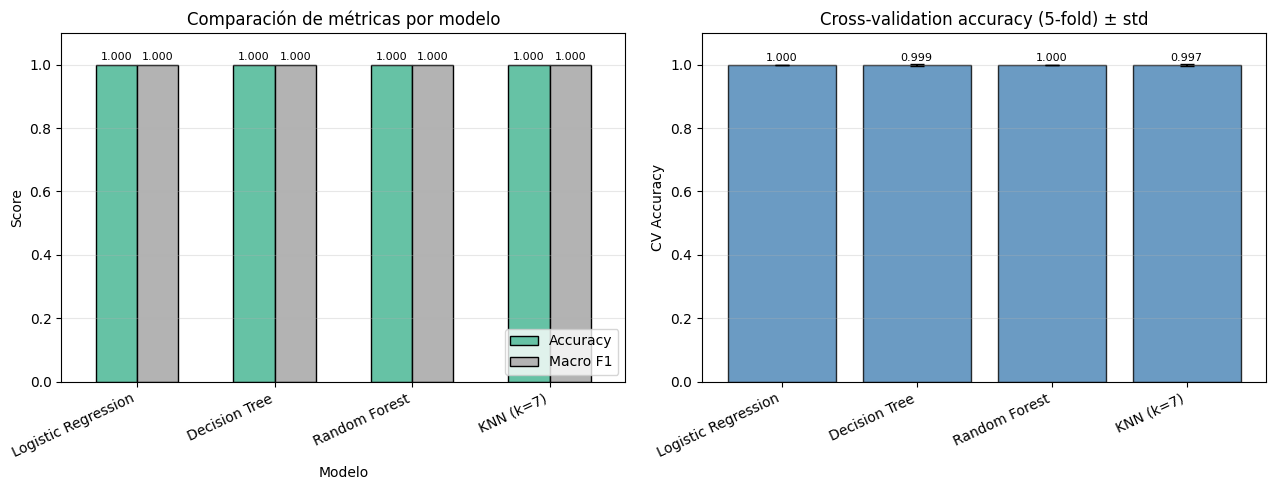

Guardado: comparacion_modelos.png


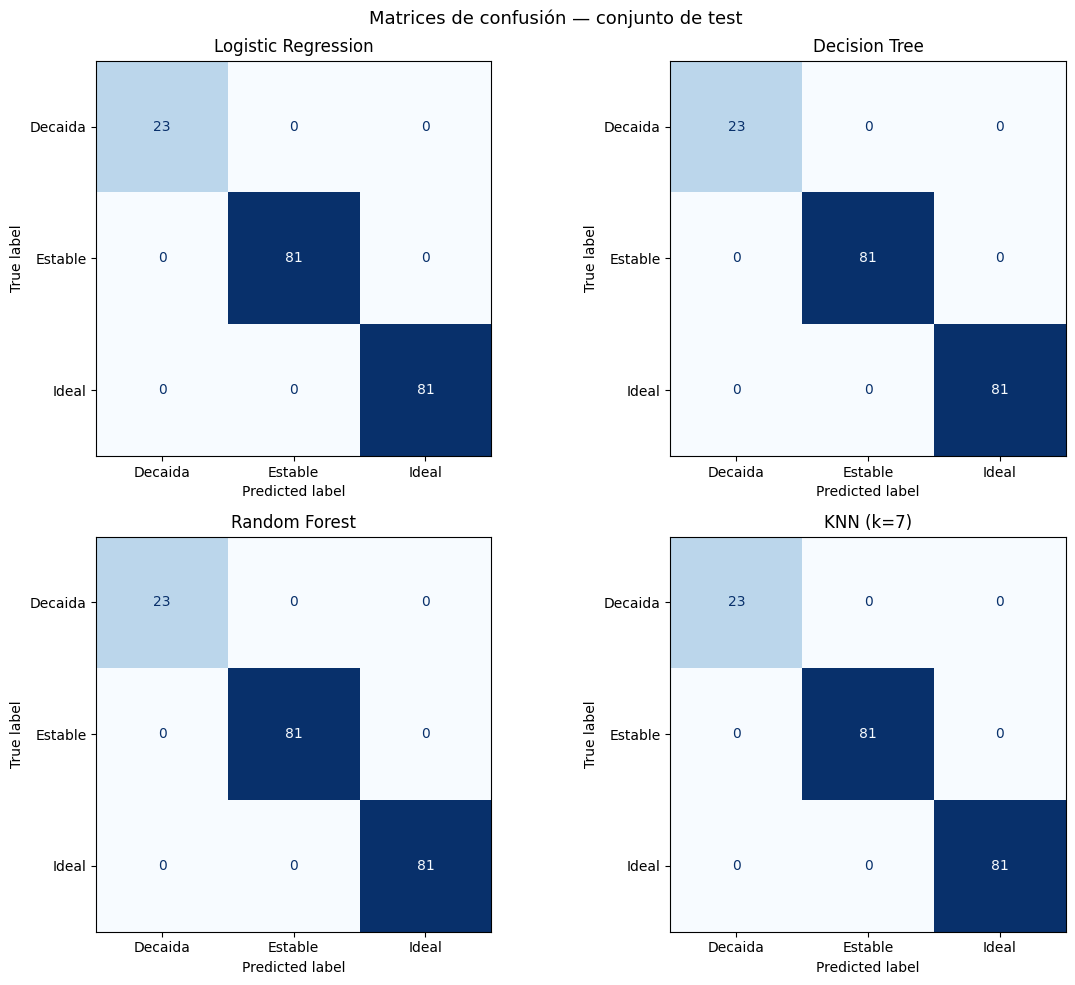

Guardado: confusion_matrices.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Barchart accuracy y macro F1 ---
df_plot = df_results[['Accuracy', 'Macro F1']].copy()
df_plot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black', width=0.6)
axes[0].set_title('Comparación de métricas por modelo')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha='right')
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=8, padding=2)

# --- CV accuracy con barras de error ---
cv_means = df_results['CV mean'].values
cv_stds  = df_results['CV std'].values
x = list(range(len(df_results)))
axes[1].bar(x, cv_means, yerr=cv_stds, capsize=5,
            color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_results.index, rotation=25, ha='right')
axes[1].set_title('Cross-validation accuracy (5-fold) ± std')
axes[1].set_ylabel('CV Accuracy')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    axes[1].text(i, m + s + 0.01, f'{m:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: comparacion_modelos.png")

# --- Matrices de confusión 2x2 ---
class_names = ['Decaida', 'Estable', 'Ideal']
fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, (clf, Xtr, Xte)) in zip(axes2.flat, trained.items()):
    y_pred = clf.predict(Xte)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)
plt.suptitle('Matrices de confusión — conjunto de test', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: confusion_matrices.png")


### 5. Modelo seleccionado: Decision Tree

El **Decision Tree** (max_depth=5) es elegido para la ESP32 por su equilibrio entre rendimiento y feasibilidad embebida:

| Criterio | Decision Tree | Random Forest | KNN | Logistic Reg. |
|---|---|---|---|---|
| Exportable como C puro | ✓ reglas if/else | ✗ múltiples árboles | ✗ necesita dataset | ✗ exp() / matmul |
| Footprint en flash | ~cientos de bytes | ~decenas de KB | ~cientos de KB | ~bytes |
| Sin librerías externas | ✓ | ✗ | ✗ | ✓ |
| Rendimiento (macro F1) | competitivo | mejor | comparable | menor |

El árbol con profundidad 5 genera como máximo 31 nodos, lo que resulta en código C completamente inlineable y ejecutable en microsegundos.

In [11]:
dt_clf = trained['Decision Tree'][0]

print("=== Classification Report — Decision Tree ===\n")
y_pred_dt = dt_clf.predict(X_test)
print(classification_report(y_test, y_pred_dt, target_names=['Decaida', 'Estable', 'Ideal']))

print("\nImportancia de features:")
for feat, imp in sorted(zip(feature_cols, dt_clf.feature_importances_), key=lambda x: -x[1]):
    bar = '█' * int(imp * 40)
    print(f"  {feat:<18}  {imp:.4f}  {bar}")


=== Classification Report — Decision Tree ===

              precision    recall  f1-score   support

     Decaida       1.00      1.00      1.00        23
     Estable       1.00      1.00      1.00        81
       Ideal       1.00      1.00      1.00        81

    accuracy                           1.00       185
   macro avg       1.00      1.00      1.00       185
weighted avg       1.00      1.00      1.00       185


Importancia de features:
  luz                 0.6143  ████████████████████████
  humedad_suelo       0.3244  ████████████
  temperatura         0.0614  ██


### 6. Export del modelo para ESP32

El Decision Tree se traduce directamente a código C con reglas `if/else`. Usa valores **RAW** del sensor (sin normalizar) ya que el árbol fue entrenado sobre `X_train` sin escalar. El código resultante puede copiarse directamente al firmware de la ESP32 sin dependencias externas.

In [12]:
from sklearn.tree import _tree

def tree_to_c(clf, feature_names, class_names):
    tree_ = clf.tree_
    fn = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined"
        for i in tree_.feature
    ]
    lines = []
    lines.append("// Decision Tree — inferencia en la ESP32")
    lines.append("// Entrada: valores RAW del sensor (sin normalizar)")
    lines.append("// Retorna: 0=Decaida  1=Estable  2=Ideal")
    lines.append("")
    params = ", ".join(f"float {n}" for n in feature_names)
    lines.append(f"int predict_plant_condition({params}) {{")

    def recurse(node, depth):
        pad = "    " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            feat = fn[node]
            thr  = tree_.threshold[node]
            lines.append(f"{pad}if ({feat} <= {thr:.4f}f) {{")
            recurse(tree_.children_left[node],  depth + 1)
            lines.append(f"{pad}}} else {{")
            recurse(tree_.children_right[node], depth + 1)
            lines.append(f"{pad}}}")
        else:
            cls  = int(tree_.value[node].flatten().argmax())
            name = class_names[cls]
            lines.append(f"{pad}return {cls};  // {name}")

    recurse(0, 1)
    lines.append("}")
    return "\n".join(lines)

c_code = tree_to_c(dt_clf, feature_cols, ['Decaida', 'Estable', 'Ideal'])
print(c_code)


// Decision Tree — inferencia en la ESP32
// Entrada: valores RAW del sensor (sin normalizar)
// Retorna: 0=Decaida  1=Estable  2=Ideal

int predict_plant_condition(float temperatura, float luz, float humedad_suelo) {
    if (luz <= 2922.0000f) {
        return 2;  // Ideal
    } else {
        if (humedad_suelo <= 1798.0000f) {
            if (temperatura <= 11.3250f) {
                return 0;  // Decaida
            } else {
                return 2;  // Ideal
            }
        } else {
            return 1;  // Estable
        }
    }
}
